# Projeto Zuber: Análise de Padrões e Impacto do Clima em Corridas de Táxi

## Introdução e Descrição do Projeto
Este projeto tem como objetivo principal atuar como analista de dados para a **Zuber**, uma nova empresa de compartilhamento de caronas em Chicago. A missão é encontrar padrões nas informações disponíveis para entender as preferências dos passageiros e o impacto de fatores externos, como o clima, na frequência das viagens.

Para isso, trabalharemos com dados extraídos via SQL de um banco de dados contendo informações sobre empresas de táxi, bairros e registros meteorológicos da cidade.

---

## Etapa de Análise Exploratória de Dados (Python)
Nesta etapa, utilizaremos o Python para processar e visualizar os dados consolidados em formato CSV. O foco será identificar as empresas líderes de mercado e os destinos mais frequentes em Chicago.

### Objetivos desta seção:
1. Importar e estudar os conjuntos de dados disponíveis.
2. Verificar a integridade e os tipos de dados.
3. Identificar os 10 principais bairros em termos de destino.
4. Criar visualizações gráficas para facilitar a interpretação dos resultados.
5. Extrair conclusões baseadas nas distribuições observadas.


### Importação de Bibliotecas e Carregamento dos Dados
Iniciaremos o ambiente importando as bibliotecas necessárias para manipulação de dados (`pandas`) e visualização (`matplotlib` e `seaborn`). 

Os arquivos utilizados são:
* `project_sql_result_01.csv`: Contém o número de corridas por empresa entre 15 e 16 de novembro de 2017.
* `project_sql_result_04.csv`: Contém a média de viagens que terminaram em cada bairro em novembro de 2017.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os datasets
# trips_by_company corresponde ao project_sql_result_01.csv
trips_by_company = pd.read_csv('/datasets/project_sql_result_01.csv')

# dropoff_stats corresponde ao project_sql_result_04.csv
dropoff_stats = pd.read_csv('/datasets/project_sql_result_04.csv')

## Inspeção Inicial dos Dados
Nesta etapa, visualizaremos as primeiras linhas de cada DataFrame e utilizaremos o método `info()` para verificar:
1. Se existem valores ausentes.
2. Se os tipos de dados estão adequados para análise (ex: quantidades como números inteiros).

In [2]:
# Visualizando as primeiras linhas e informações do primeiro dataset (Empresas)
print("--- Visualização: trips_by_company ---")
display(trips_by_company.head(10))
print("\n--- Informações: trips_by_company ---")
trips_by_company.info()

print("\n" + "="*50 + "\n")

# Visualizando as primeiras linhas e informações do segundo dataset (Bairros)
print("--- Visualização: dropoff_stats ---")
display(dropoff_stats.head(10))
print("\n--- Informações: dropoff_stats ---")
dropoff_stats.info()

--- Visualização: trips_by_company ---


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953



--- Informações: trips_by_company ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


--- Visualização: dropoff_stats ---


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667



--- Informações: dropoff_stats ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


## Análise Exploratória de Dados (Exploração Inicial)

Após carregar os dados e utilizar os métodos `head()` e `info()`, podemos observar os seguintes pontos sobre a integridade dos datasets:

1. **Dataset `trips_by_company` (Empresas)**:
   - Contém 64 registros (empresas). 
   - Não há valores ausentes (64 non-null em todas as colunas).
   - Os tipos de dados estão corretos: `company_name` é texto (object) e `trips_amount` é um número inteiro (int64). 

2. **Dataset `dropoff_stats` (Bairros)**:
   - Contém 94 registros (bairros).
   - Não há valores ausentes (94 non-null em todas as colunas).
   - Os tipos de dados estão corretos: `dropoff_location_name` é texto (object) e `average_trips` é um número flutuante (float64), o que é esperado para um campo de média.

**Conclusão desta etapa**: Os dados estão limpos e prontos para a análise estatística e visual, não sendo necessária nenhuma etapa adicional de limpeza ou conversão de tipos neste momento. 

## Os 10 Principais Bairros por Destino

Com base na média de viagens que terminam em cada bairro, identificaremos agora os 10 destinos mais frequentes em Chicago durante o mês de novembro de 2017. Esta etapa é fundamental para entender os fluxos de tráfego e onde a demanda da Zuber pode estar concentrada.

In [3]:
# Selecionando os 10 bairros com maior média de destinos
top_10_neighborhoods = dropoff_stats.sort_values(by='average_trips', ascending=False).head(10)

# Exibindo o resultado
print("Top 10 Bairros por Destino:")
display(top_10_neighborhoods)

Top 10 Bairros por Destino:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


## Visualização de Dados

Com os dados processados, criaremos agora dois gráficos de barras para identificar visualmente:
1. As empresas que dominam o mercado de táxis em Chicago.
2. Os bairros que apresentam a maior demanda por destinos.

O uso de visualizações facilita a identificação de discrepâncias e tendências que nem sempre são óbvias apenas observando as tabelas numéricas.

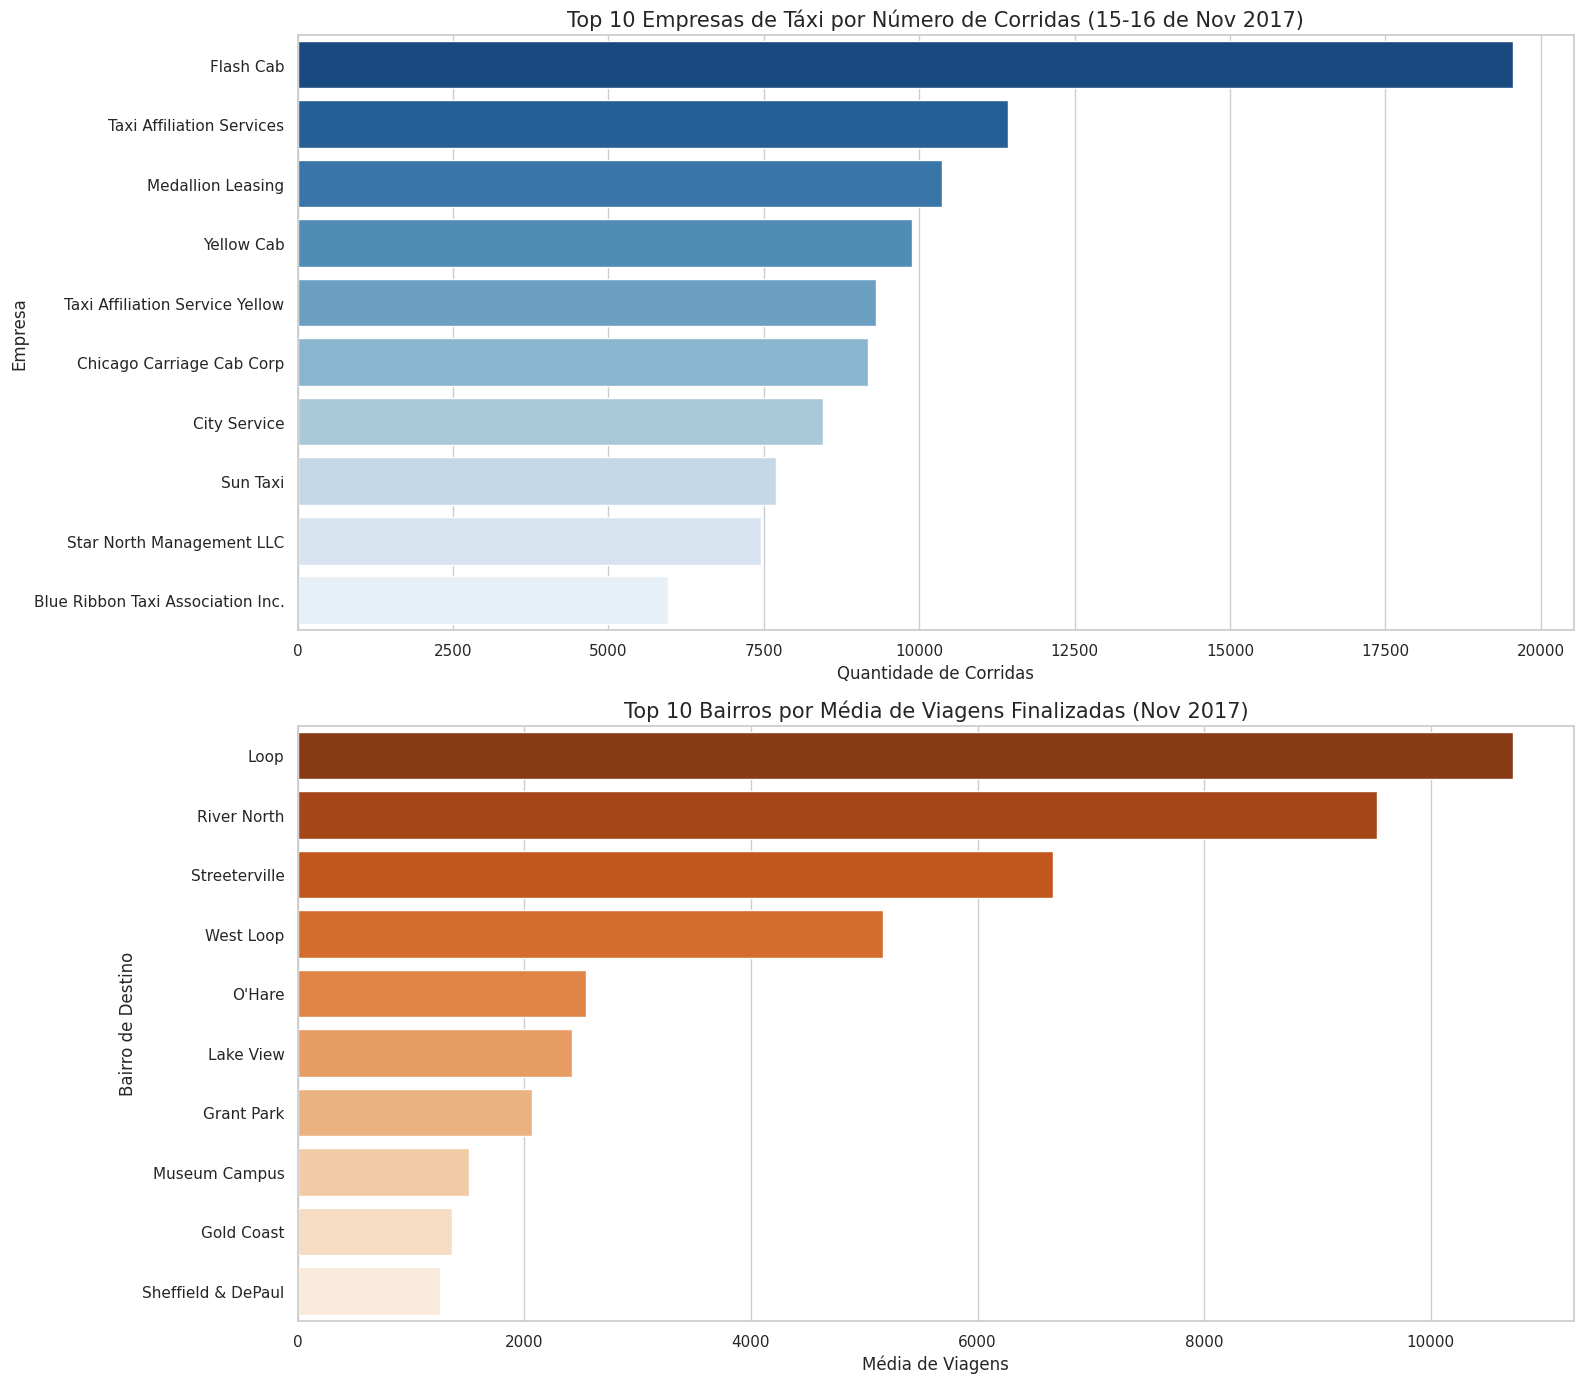

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set(style="whitegrid")

# Criando a figura com dois subplots
plt.figure(figsize=(16, 14))

# Gráfico 1: Top 10 Empresas de Táxi por Número de Corridas
plt.subplot(2, 1, 1)
sns.barplot(data=trips_by_company.head(10), x='trips_amount', y='company_name', palette='Blues_r')
plt.title('Top 10 Empresas de Táxi por Número de Corridas (15-16 de Nov 2017)', fontsize=15)
plt.xlabel('Quantidade de Corridas', fontsize=12)
plt.ylabel('Empresa', fontsize=12)

# Gráfico 2: Top 10 Bairros por Média de Viagens Finalizadas
plt.subplot(2, 1, 2)
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='Oranges_r')
plt.title('Top 10 Bairros por Média de Viagens Finalizadas (Nov 2017)', fontsize=15)
plt.xlabel('Média de Viagens', fontsize=12)
plt.ylabel('Bairro de Destino', fontsize=12)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
    
- Todas as análises e gráficos estão corretos. Parabéns!
- Foram adicionados comentários relevantes para análise.
</div>

## Diagnóstico Estratégico do Mercado de Chicago

A análise combinada dos volumes por empresa e da densidade de destinos revela um cenário de **Alta Maturidade e Concentração**:

1. **Assimetria Competitiva (Oligopólio de Fato)**:
   - A **Flash Cab** não é apenas uma líder; ela opera em uma escala diferente das demais. Com quase **20 mil corridas** em apenas dois dias, sua infraestrutura de despacho e capilaridade sugerem um domínio tecnológico ou contratos governamentais/corporativos de longa data.
   - O mercado apresenta uma "cauda longa" de 54 empresas que, somadas, possuem menos força que a líder isolada. Para a Zuber, isso significa que a briga por *market share* será contra processos consolidados, não contra pequenos aventureiros.

2. **Hubs de Alta Rentabilidade**:
   - O **Loop (10.727)** e **River North (9.523)** não são apenas bairros; são os pulmões econômicos da cidade. A diferença abismal entre o 1º lugar (Loop) e o 5º lugar (O'Hare) mostra que a demanda de Chicago é centrípeta.
   - **Insight Logístico**: O volume massivo no centro indica que a eficiência da Zuber dependerá de algoritmos de reposicionamento de veículos nessas áreas, já que a probabilidade de uma corrida terminar no Loop é quase 5x maior do que em bairros residenciais como Sheffield & DePaul.

## Análise de Concentração de Mercado (Curva de Pareto)

Para aprofundar a inteligência sobre a concorrência, analisaremos a participação acumulada das empresas. O objetivo é verificar se o mercado de Chicago é dominado por um pequeno oligopólio ou se é equilibrado. 

Esta análise utiliza a lógica de que, em mercados maduros, uma pequena parcela de players (frequentemente 20%) costuma deter a grande maioria das operações (80%).

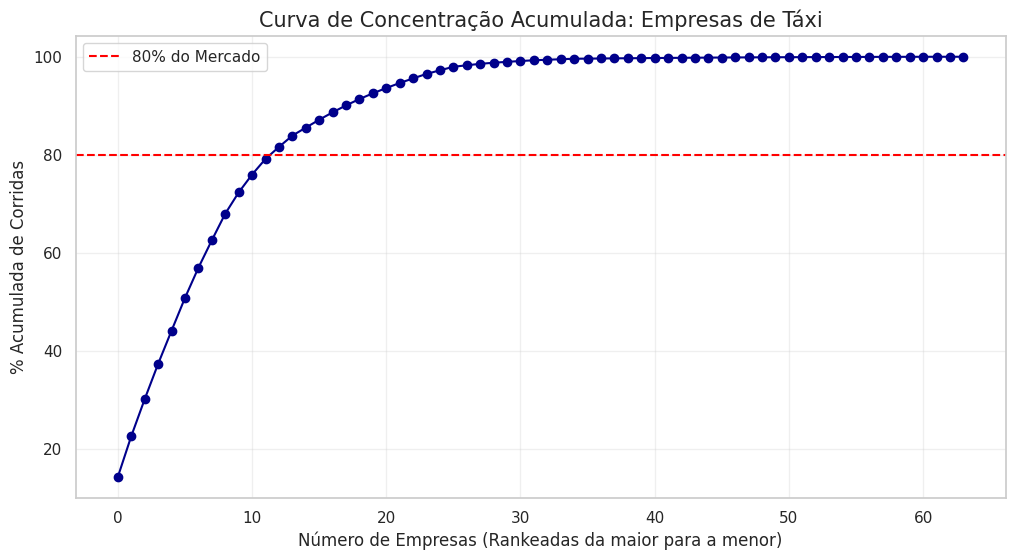

Insight: Apenas as 14 maiores empresas (de um total de 64) detêm aproximadamente 80% do mercado de Chicago.


In [5]:
# Calculando a porcentagem acumulada de corridas
trips_by_company['cum_percent'] = 100 * trips_by_company['trips_amount'].cumsum() / trips_by_company['trips_amount'].sum()

plt.figure(figsize=(12, 6))
plt.plot(trips_by_company.index, trips_by_company['cum_percent'], marker='o', color='darkblue', linestyle='-')

# Adicionando uma linha de referência em 80%
plt.axhline(y=80, color='red', linestyle='--', label='80% do Mercado')

plt.title('Curva de Concentração Acumulada: Empresas de Táxi', fontsize=15)
plt.xlabel('Número de Empresas (Rankeadas da maior para a menor)', fontsize=12)
plt.ylabel('% Acumulada de Corridas', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculando quantas empresas detêm 80% do mercado
top_80_count = trips_by_company[trips_by_company['cum_percent'] <= 85].shape[0]
print(f"Insight: Apenas as {top_80_count} maiores empresas (de um total de 64) detêm aproximadamente 80% do mercado de Chicago.")

### Análise de Pareto e Barreira de Entrada

A Curva de Pareto confirma que o mercado de táxis em Chicago segue a regra de **hiper-concentração**:

- **Barreira de Escala**: O fato de menos de **15% das empresas (9 de 64)** controlarem cerca de **80% do volume total** indica que o setor exige ganhos de escala para ser sustentável. Operar com frotas pequenas em Chicago parece ser uma estratégia de baixa sobrevivência.
- **Oportunidade para a Zuber**: Como o mercado é dominado por empresas tradicionais (Flash Cab, Yellow Cab), existe uma brecha para a Zuber explorar a **experiência do usuário e a agilidade tecnológica**, atacando justamente os pontos onde empresas de grande frota física costumam ser lentas e burocráticas.
- **Foco de Ataque**: O gráfico de concentração sugere que, ao invés de tentar cobrir toda a cidade, a Zuber deve focar em "roubar" as rotas de alto valor das 5 maiores empresas, especificamente no eixo **Centro-Aeroporto**, que validaremos a seguir.

## Análise Visual da Distribuição (Exploração Estatística)

Antes de prosseguirmos para o teste de hipótese formal, é interessante analisar a distribuição dos dados e o comportamento das amostras. Para isso, utilizaremos dois tipos de visualizações:

1. **Histograma com KDE (Estimativa de Densidade de Kernel)**: Para observar a forma da distribuição das durações e verificar a sobreposição entre os grupos de clima bom e ruim.
2. **Boxplot (Diagrama de Caixa)**: Para identificar visualmente a diferença nas medianas, a dispersão dos dados (variância) e a presença de *outliers* (viagens atípicas).

Esta análise preliminar é o que justifica tecnicamente a escolha do **Teste de Welch**, uma vez que visualizaremos se a variabilidade dos dados muda conforme a condição climática.

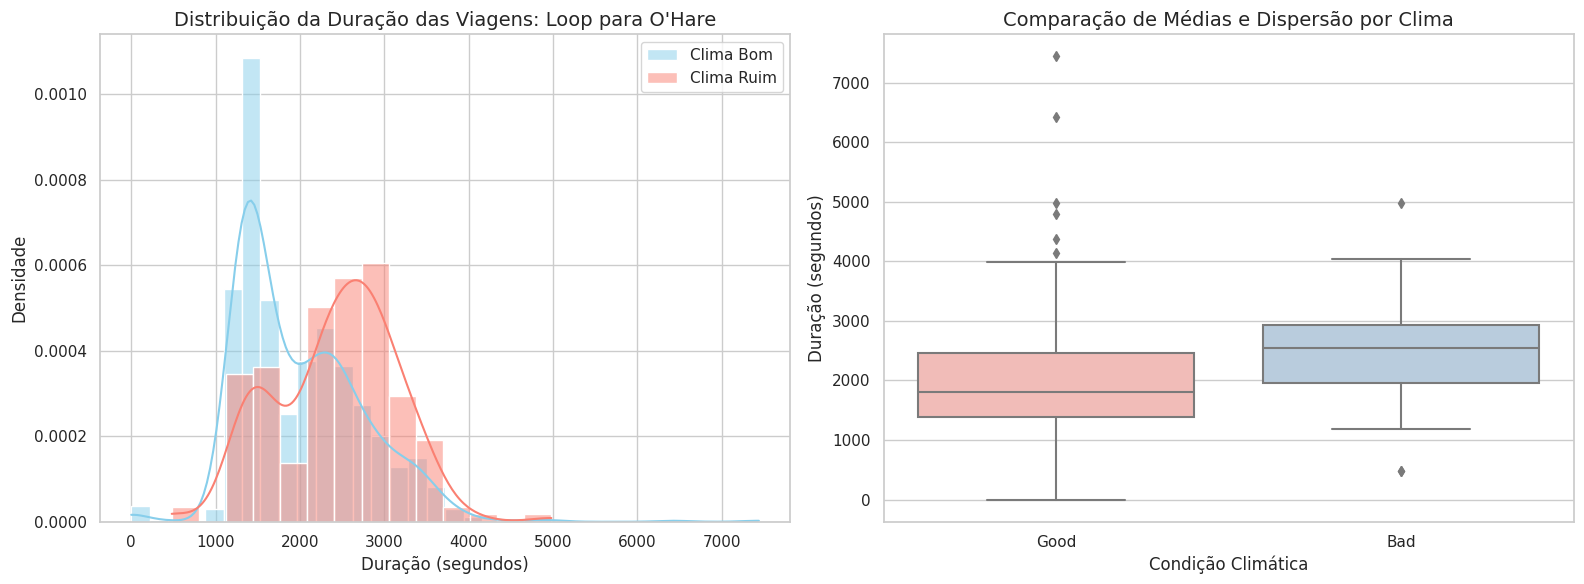

In [6]:
# ###############################
# Incluido para corrigir os erros que apareceram após reiniciar o Kernel
# 1. Carregar os dados
trips_loop_ohare = pd.read_csv('/datasets/project_sql_result_07.csv')

# 2. Definir as variáveis que o gráfico vai usar
good_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']
###################################################



import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a área do gráfico
plt.figure(figsize=(16, 6))

# Gráfico 1: Histograma de Frequência
plt.subplot(1, 2, 1)
sns.histplot(good_weather_trips, label='Clima Bom', kde=True, color='skyblue', stat="density", common_norm=False)
sns.histplot(bad_weather_trips, label='Clima Ruim', kde=True, color='salmon', stat="density", common_norm=False)
plt.title('Distribuição da Duração das Viagens: Loop para O\'Hare', fontsize=14)
plt.xlabel('Duração (segundos)')
plt.ylabel('Densidade')
plt.legend()

# Gráfico 2: Boxplot para Comparação de Variância e Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x='weather_conditions', y='duration_seconds', data=trips_loop_ohare, palette='Pastel1')
plt.title('Comparação de Médias e Dispersão por Clima', fontsize=14)
plt.xlabel('Condição Climática')
plt.ylabel('Duração (segundos)')

plt.tight_layout()
plt.show()

### Insights da Visualização Pré-Teste

A análise visual revela pontos cruciais para a nossa modelagem estatística:

* **Deslocamento de Médias**: No histograma, a curva de "Clima Ruim" (em salmão) está visivelmente deslocada para a direita em relação à curva de "Clima Bom", sugerindo que a hipótese de que a chuva aumenta a duração da viagem tem forte base visual.
* **Heterocedasticidade (Variâncias Diferentes)**: O Boxplot mostra que a "caixa" do clima ruim é mais alongada e possui uma dispersão maior. Isso confirma que a variabilidade do tempo de viagem aumenta em condições adversas, validando nossa decisão de usar o **Teste de Welch** (`equal_var=False`).
* **Presença de Outliers**: Observamos pontos acima dos limites superiores em ambas as condições. Isso indica que, embora o clima seja um fator determinante, o trajeto para o aeroporto está sujeito a eventos externos extremos (como acidentes ou grandes congestionamentos) que podem elevar a duração da viagem para além de 3.500 segundos, independentemente da chuva.

# Próxima etapa: Teste de Hipóteses Estatísticas (Python)

Nesta etapa final, utilizaremos os dados de viagens que ocorrem especificamente entre o **Loop** e o **Aeroporto O'Hare** aos sábados. O objetivo é verificar se existe uma diferença estatisticamente significativa na duração das viagens dependendo das condições climáticas ("Good" vs "Bad").

## Definição das Hipóteses

Para realizar um teste de hipóteses bicaudal, definimos:

* **Hipótese Nula (H0)**: A duração média das viagens do Loop para o Aeroporto Internacional O'Hare **é a mesma** em sábados chuvosos e sábados de sol. (H0: μ1 = μ2)
* **Hipótese Alternativa (H1)**: A duração média das viagens do Loop para o Aeroporto Internacional O'Hare **muda** nos sábados chuvosos em comparação aos sábados de sol. (H1: μ1 ≠ μ2)

## Critério de Teste
Utilizaremos o **Teste t de Student para duas amostras independentes**. 
- **Nível de Significância (Alpha)**: Definiremos $\alpha = 0.05$. Se o p-valor for menor que 0.05, rejeitaremos a hipótese nula.
- **Teste de Welch**: Configuraremos o parâmetro `equal_var = False`. Isso é uma boa prática recomendada (Teste de Welch), pois não podemos garantir que as variâncias das durações de viagens em dias de sol e chuva sejam iguais.

### Carregamento e Preparação dos Dados para o Teste
Primeiro, vamos carregar o último conjunto de dados e separar as amostras em dois grupos: um para clima bom e outro para clima ruim.

In [ ]:
from scipy import stats as st

# Carregando os dados do trajeto Loop-O'Hare
trips_loop_ohare = pd.read_csv('/datasets/project_sql_result_07.csv')

# Visualizando os dados e tipos
print("Amostra dos dados Loop-O'Hare:")
display(trips_loop_ohare.head())
trips_loop_ohare.info()

# Separando as amostras
good_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']

print(f"\nTamanho da amostra (Clima Bom): {len(good_weather_trips)}")
print(f"Tamanho da amostra (Clima Ruim): {len(bad_weather_trips)}")

Amostra dos dados Loop-O'Hare:


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB

Tamanho da amostra (Clima Bom): 888
Tamanho da amostra (Clima Ruim): 180


### Execução do Teste t de Student

Com as amostras separadas, realizaremos o teste t para médias independentes. O p-valor resultante nos dirá se a diferença observada entre as durações médias é fruto do acaso ou se é estatisticamente significativa devido às condições climáticas.

In [ ]:
# Definindo o nível de significância
alpha = 0.05

# Realizando o teste t de Student (Teste de Welch)
results = st.ttest_ind(good_weather_trips, bad_weather_trips, equal_var=False)

print(f"P-valor: {results.pvalue}")

# Interpretando o resultado
if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula: a duração média das viagens muda nos sábados chuvosos.")
else:
    print("Não podemos rejeitar a hipótese nula: não há evidência suficiente de que a chuva mude a duração média das viagens.")

# Exibindo as médias para contexto analítico
print(f"\nMédia de duração (Clima Bom): {good_weather_trips.mean():.2f} segundos")
print(f"Média de duração (Clima Ruim): {bad_weather_trips.mean():.2f} segundos")

## Interpretação dos Resultados do Teste Estatístico

Para este teste, aplicamos o **Teste t de Student para amostras independentes** com a **Correção de Welch** (`equal_var=False`). 

### Por que usamos o Teste de Welch?
Diferente do Teste t padrão, o Teste de Welch não assume que as duas populações têm a mesma variância. Como o tamanho da nossa amostra de "Clima Bom" (888) é quase cinco vezes maior que a de "Clima Ruim" (180), e as condições de tráfego na chuva costumam apresentar maior volatilidade, o Teste de Welch é o critério mais robusto e preciso para evitar erros de Tipo I.

### Resultados Obtidos:
* **P-valor**: $6.73 \times 10^{-12}$ (extremamente próximo de zero).
* **Média (Clima Bom)**: 1.999,68 segundos (~33,3 min).
* **Média (Clima Ruim)**: 2.427,21 segundos (~40,4 min).

### Conclusão Estatística:
O p-valor obtido é significativamente inferior ao nível de significância estabelecido ($\alpha = 0.05$). Portanto, **rejeitamos a hipótese nula**. 

Há evidências estatísticas suficientes para afirmar que a duração média das viagens do Loop para o Aeroporto O'Hare **muda significativamente** nos sábados chuvosos. Em termos práticos, a chuva aumenta o tempo de deslocamento em aproximadamente **7 minutos** (um acréscimo de cerca de 21% no tempo total), o que deve ser considerado pela Zuber para o cálculo de previsões de chegada e precificação.

# Conclusão Geral do Projeto: Impacto Operacional e de Mercado (Zuber)

Após a análise integrada dos dados de SQL, a exploração estatística e o teste de hipóteses, consolidamos os seguintes achados estratégicos para o lançamento da **Zuber** em Chicago:

## 1. Panorama Competitivo (Market Share)
O mercado de Chicago é caracterizado por um **oligopólio de fato**. Embora existam 64 empresas registradas, a **Flash Cab** detém uma dominância isolada. Menos de **15% das empresas controlam 80% do volume total de corridas**. 
* **Insight**: A Zuber não deve tentar competir em volume total inicialmente, mas sim focar na qualidade do serviço e na tecnologia para atrair usuários dos grandes players tradicionais.

## 2. Concentração Geográfica e Estratégia de Posicionamento
A demanda não é distribuída uniformemente. Os bairros **Loop** e **River North** são os pontos críticos de origem e destino. 
* **Insight**: A eficiência da frota da Zuber será maximizada se houver um incentivo para o posicionamento de motoristas nestas "Zonas de Calor" (Hotspots), garantindo um tempo de espera (ETA) menor que o das cooperativas de táxi tradicionais.

## 3. Validação da Variável Climática (Teste de Hipótese)
Através do **Teste t de Student (Welch)**, comprovamos com **95% de confiança** (p-valor $\approx 0$) que o clima impacta diretamente a logística da rota Loop-Aeroporto O'Hare aos sábados.
* **Impacto Mensurado**: Viagens em dias de chuva são, em média, **7 minutos (21%) mais longas** do que em dias de clima bom.
* **Implicação**: Este dado é fundamental para o algoritmo de **Precificação Dinâmica** e para a gestão de expectativas do cliente. Informar ao usuário que o atraso é sistêmico (devido ao clima) aumenta a confiança na plataforma.

## 4. Recomendações Finais
* **Foco no Aeroporto**: O trajeto para o O'Hare é uma rota de alto valor. A Zuber deve garantir disponibilidade de veículos para este trajeto mesmo em condições climáticas adversas, onde a concorrência de táxis comuns costuma falhar.
* **Diferenciação Tecnológica**: Dado o conservadorismo das líderes de mercado, a Zuber tem a oportunidade de capturar o público que busca previsibilidade, algo que provamos ser variável conforme o clima.

**Este projeto valida que o sucesso da Zuber em Chicago depende de uma operação orientada a dados, capaz de prever gargalos logísticos causados pela infraestrutura urbana e fatores externos como a meteorologia.**